# Typhoon trajectory LSTM → nearest prefecture
Predict Day 0 cyclone coordinates from Day −3, −2, −1 observations, then derive the nearest Japanese prefecture using the same GIS polygons as preprocessing. **Only confirmed-landfall sequences exist in this dataset**; this is not a model of whether a cyclone will form or make landfall.

Run cells in order. Install `tensorflow pandas numpy scikit-learn matplotlib joblib geopandas pyogrio` if needed. For best results, use more complete cyclone trajectories in future.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)

## 1. Paths and configuration

In [22]:
# Adjust these paths for your project layout.
PROJECT = Path.cwd()
CANDIDATES = [
    PROJECT / "data/processed/jma_day3_to_landfall_with_weather_prefecture.csv",
    PROJECT.parent / "data/processed/jma_day3_to_landfall_with_weather_prefecture.csv",
    PROJECT / "jma_day3_to_landfall_with_weather_prefecture.csv",
    Path("/mnt/data/jma_day3_to_landfall_with_weather_prefecture.csv"),
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), CANDIDATES[0])
OUT = (PROJECT if PROJECT.name == "training" else PROJECT / "training") / "trained_models" / "nearest_prefecture"
OUT.mkdir(exist_ok=True, parents=True)
# Set to the actual .shp file inside data/gis/jp_shp to enable prefecture prediction.
GIS_ROOT = PROJECT.parent if PROJECT.name == "training" else PROJECT
GIS_FOLDER = GIS_ROOT / "data" / "gis"

shapefiles = list(GIS_FOLDER.rglob("*.shp"))

if not shapefiles:
    raise FileNotFoundError(f"No .shp files found in {GIS_FOLDER}")

print("Available shapefiles:")
for shp in shapefiles:
    print(shp)

SHAPEFILE = shapefiles[0]

print("Using shapefile:", SHAPEFILE)
print("GIS file exists:", SHAPEFILE.exists())
print("Dataset:", DATA_PATH)

Available shapefiles:
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\ad.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\af.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\al.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\am.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\ao.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\aq.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\data\gis\jp_shp\ar.shp
c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\CO

## 2. Load and validate

In [23]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
required = {"landfall_event_id", "intl_id", "relative_day", "latitude", "longitude", "nearest_prefecture"}
assert required.issubset(df.columns), f"Missing: {required - set(df.columns)}"
print("Rows:", len(df), "Events:", df.landfall_event_id.nunique(), "Storm IDs:", df.intl_id.nunique())
print(df.relative_day.value_counts().to_string())

Rows: 788 Events: 200 Storm IDs: 102
relative_day
Day -1    200
Day 0     200
Day -2    199
Day -3    189


## 3. Select predictors
JMA cyclone **latitude and longitude are retained** as trajectory inputs. Other JMA attributes, labels, IDs, and future Day 0 values are **not** predictors. Weather variables must be available for the observation days.

In [24]:
WEATHER = [
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "relative_humidity_2m_mean", "relative_humidity_2m_max", "relative_humidity_2m_min",
    "dew_point_2m_mean", "dew_point_2m_max", "dew_point_2m_min",
    "precipitation_sum", "rain_sum", "precipitation_hours",
    "cloud_cover_mean", "cloud_cover_max", "cloud_cover_min",
    "pressure_msl_mean", "pressure_msl_max", "pressure_msl_min",
    "surface_pressure_mean", "surface_pressure_max", "surface_pressure_min",
    "wind_speed_10m_mean", "wind_speed_10m_max", "wind_speed_10m_min",
    "wind_gusts_10m_mean", "wind_gusts_10m_max", "wind_gusts_10m_min",
    "wind_direction_10m_dominant", "shortwave_radiation_sum"
]
FEATURES = ["latitude", "longitude"] + [c for c in WEATHER if c in df.columns]
assert all(c in df.columns for c in FEATURES)
print(f"{len(FEATURES)} predictors:", FEATURES)

31 predictors: ['latitude', 'longitude', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'dew_point_2m_mean', 'dew_point_2m_max', 'dew_point_2m_min', 'precipitation_sum', 'rain_sum', 'precipitation_hours', 'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min', 'pressure_msl_mean', 'pressure_msl_max', 'pressure_msl_min', 'surface_pressure_mean', 'surface_pressure_max', 'surface_pressure_min', 'wind_speed_10m_mean', 'wind_speed_10m_max', 'wind_speed_10m_min', 'wind_gusts_10m_mean', 'wind_gusts_10m_max', 'wind_gusts_10m_min', 'wind_direction_10m_dominant', 'shortwave_radiation_sum']


## 4. Construct Day −3/−2/−1 → Day 0 sequences

In [25]:
DAY_ORDER = ["Day -3", "Day -2", "Day -1", "Day 0"]
sequences, targets, meta = [], [], []
for event_id, part in df.groupby("landfall_event_id", sort=False):
    if any((part.relative_day == d).sum() != 1 for d in DAY_ORDER):
        continue
    part = part.set_index("relative_day").loc[DAY_ORDER]
    # Do not use Day 0 features to predict Day 0.
    x = part.iloc[:3][FEATURES].apply(pd.to_numeric, errors="coerce").to_numpy(dtype="float32")
    y = part.iloc[3][["latitude", "longitude"]].to_numpy(dtype="float32")
    if not np.isfinite(y).all():
        continue
    sequences.append(x)
    targets.append(y)
    meta.append({"event_id": event_id, "storm_id": str(part.iloc[0]["intl_id"]),
                 "actual_prefecture": part.iloc[3]["nearest_prefecture"]})
X = np.asarray(sequences, dtype="float32")
y = np.asarray(targets, dtype="float32")
meta = pd.DataFrame(meta)
print("X:", X.shape, "y:", y.shape, "storms:", meta.storm_id.nunique())
assert len(X) >= 20, "Too few complete events"

X: (189, 3, 31) y: (189, 2) storms: 99


## 5. Split by storm ID (not event)
Events from the same storm can overlap in time. Grouping by `intl_id` reduces train/test leakage.

In [26]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=meta.storm_id))
assert set(meta.iloc[train_idx].storm_id).isdisjoint(set(meta.iloc[test_idx].storm_id))
print("Train events:", len(train_idx), "Test events:", len(test_idx))
print("Train storms:", meta.iloc[train_idx].storm_id.nunique(), "Test storms:", meta.iloc[test_idx].storm_id.nunique())

Train events: 145 Test events: 44
Train storms: 79 Test storms: 20


## 6. Fit preprocessing on training data only

In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median", keep_empty_features=True)
scaler_x, scaler_y = StandardScaler(), StandardScaler()
num_features = X.shape[-1]
X_train_flat = X[train_idx].reshape(-1, num_features)
imputer.fit(X_train_flat)
scaler_x.fit(imputer.transform(X_train_flat))
scaler_y.fit(y[train_idx])
def transform_x(a):
    flat = a.reshape(-1, num_features)
    return scaler_x.transform(imputer.transform(flat)).reshape(a.shape).astype("float32")
X_train, X_test = transform_x(X[train_idx]), transform_x(X[test_idx])
y_train, y_test = scaler_y.transform(y[train_idx]), scaler_y.transform(y[test_idx])
joblib.dump({"features": FEATURES, "imputer": imputer, "x_scaler": scaler_x,
             "y_scaler": scaler_y}, OUT / "preprocessing.joblib")

['c:\\Users\\IAN\\Desktop\\SEM (SWIN)\\SEM 2\\COS30049-Computing Technology Innovation Project\\Assignments\\Dev\\Typhoon\\training\\trained_models\\nearest_prefecture\\preprocessing.joblib']

## 7. Build and train LSTM

In [28]:
model = keras.Sequential([
    layers.Input(shape=(3, num_features)),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(2, name="future_lat_lon")
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ future_lat_lon (Dense)          │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,754 (34.20 KB)

 Trainable params: 8,754 (34.20 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Validation is drawn from the training set only; final test storms remain held out.
history = model.fit(
    X_train, y_train, epochs=150, batch_size=16,
    validation_split=0.2, shuffle=True, verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)]
)
model.save(OUT / "trajectory_lstm.keras")

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 1.1073 - mae: 0.7900 - val_loss: 0.8472 - val_mae: 0.6746
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0367 - mae: 0.7648 - val_loss: 0.8263 - val_mae: 0.6663
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9970 - mae: 0.7495 - val_loss: 0.8168 - val_mae: 0.6588
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9670 - mae: 0.7364 - val_loss: 0.8144 - val_mae: 0.6549
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9392 - mae: 0.7235 - val_loss: 0.8128 - val_mae: 0.6515
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9113 - mae: 0.7097 - val_loss: 0.8097 - val_mae: 0.6489
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8813 - mae: 0.6952 - val_loss: 0.8050 - val_mae: 0.6463
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8481 - mae: 0.6784 - val_loss: 0.8011 - val_mae: 0.6428
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8109 - mae: 

## 8. Evaluate against persistence baseline

LSTM MAE latitude (degrees): 2.831
LSTM MAE longitude (degrees): 3.324
Baseline mean coordinate absolute error (degrees): 3.195
LSTM mean coordinate absolute error (degrees): 3.077


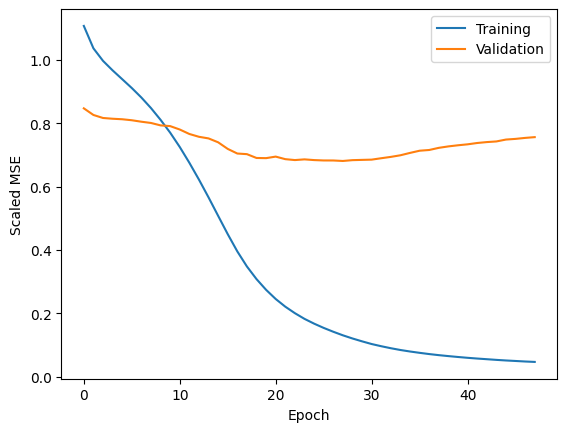

In [30]:
pred = scaler_y.inverse_transform(model.predict(X_test, verbose=0))
actual = y[test_idx]
# Baseline: tomorrow's location = last observed location.
baseline = X[test_idx, -1, :2]
print("LSTM MAE latitude (degrees):", round(mean_absolute_error(actual[:,0], pred[:,0]), 3))
print("LSTM MAE longitude (degrees):", round(mean_absolute_error(actual[:,1], pred[:,1]), 3))
print("Baseline mean coordinate absolute error (degrees):", round(np.abs(actual-baseline).mean(), 3))
print("LSTM mean coordinate absolute error (degrees):", round(np.abs(actual-pred).mean(), 3))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Scaled MSE"); plt.legend(); plt.show()

## 9. Convert coordinates to nearest prefecture (GIS required)
Set `SHAPEFILE` above to the **same prefecture polygon dataset** used by `add_nearest_prefecture.py`. The code attempts to find a prefecture-name column; adjust `NAME_COLUMN` if necessary. If the shapefile is absent, coordinate predictions are still saved, but prefecture predictions are not fabricated.

In [31]:
NAME_COLUMN = None  # e.g. "name" or "NAME_1"; leave None to auto-detect
if SHAPEFILE.exists():
    import geopandas as gpd
    from shapely.geometry import Point
    prefectures = gpd.read_file(SHAPEFILE)
    if prefectures.crs is None:
        raise ValueError("GIS layer has no CRS; define its correct CRS before continuing")
    if NAME_COLUMN is None:
        options = [c for c in prefectures.columns if c.lower() in
                   {"name", "name_1", "prefecture", "pref_name", "nam", "name_en"}]
        if not options:
            raise ValueError(f"Set NAME_COLUMN from these GIS columns: {list(prefectures.columns)}")
        NAME_COLUMN = options[0]
    # Project into meters before nearest-distance comparison.
    prefectures = prefectures.to_crs("EPSG:3857")
    def nearest_prefecture(coords):
        points = gpd.GeoSeries([Point(float(lon), float(lat)) for lat,lon in coords], crs="EPSG:4326").to_crs("EPSG:3857")
        return [str(prefectures.iloc[prefectures.geometry.distance(pt).argmin()][NAME_COLUMN]) for pt in points]
    predicted_prefectures = nearest_prefecture(pred)
    print("Prefecture prediction enabled; name field:", NAME_COLUMN)
else:
    predicted_prefectures = [None] * len(pred)
    print("GIS shapefile not found. Set SHAPEFILE to enable prefecture outputs.")

Prefecture prediction enabled; name field: name


## 10. Save predictions and report prefecture accuracy

In [32]:
results = meta.iloc[test_idx].reset_index(drop=True).copy()
results["actual_latitude"] = actual[:,0]
results["actual_longitude"] = actual[:,1]
results["predicted_latitude"] = pred[:,0]
results["predicted_longitude"] = pred[:,1]
results["predicted_nearest_prefecture"] = predicted_prefectures
if SHAPEFILE.exists():
    # Compare labels generated with the SAME GIS procedure, avoiding naming mismatches.
    actual_gis = nearest_prefecture(actual)
    results["actual_prefecture_gis"] = actual_gis
    accuracy = np.mean(np.array(predicted_prefectures) == np.array(actual_gis))
    print(f"Nearest-prefecture test accuracy: {accuracy:.2%}")
results.to_csv(OUT / "test_predictions.csv", index=False, encoding="utf-8-sig")
print("Saved:", OUT / "test_predictions.csv")
display(results.head(15))

Nearest-prefecture test accuracy: 100.00%
Saved: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Typhoon\training\trained_models\nearest_prefecture\test_predictions.csv


,event_id,storm_id,actual_prefecture,actual_latitude,actual_longitude,predicted_latitude,predicted_longitude,predicted_nearest_prefecture,actual_prefecture_gis
0,0014_2000091210,14,Okinawa,26.500000,128.000000,30.558090,131.046768,Andorra,Andorra
1,0221_2002100111,221,Kanagawa,35.299999,139.600006,32.140137,135.150314,Andorra,Andorra
2,0221_2002100121,221,Hokkaidō,42.599998,141.699997,32.140137,135.150314,Andorra,Andorra
3,0310_2003080700,310,Okinawa,26.500000,128.199997,30.952187,131.218307,Andorra,Andorra
4,0310_2003080710,310,Okinawa,28.100000,129.199997,30.952187,131.218307,Andorra,Andorra
5,0310_2003080812,310,Kōchi,33.200001,134.000000,34.667377,135.807770,Andorra,Andorra
6,0310_2003080818,310,HyÅgo,34.200001,134.800003,34.667377,135.807770,Andorra,Andorra
7,0310_2003080821,310,HyÅgo,34.700001,135.399994,34.667377,135.807770,Andorra,Andorra
8,0310_2003080916,310,Hokkaidō,41.900002,142.800003,36.709038,140.263809,Andorra,Andorra
9,0418_2004090508,418,Okinawa,26.400000,128.100006,33.299297,132.500824,Andorra,Andorra


## 11. Predict from a new observed three-day sequence

In [33]:
def predict_next_day(input_three_days):
    """DataFrame with exactly 3 chronological rows and all FEATURES columns."""
    assert len(input_three_days) == 3
    seq = input_three_days[FEATURES].apply(pd.to_numeric, errors="coerce").to_numpy(dtype="float32")[None,:,:]
    future = scaler_y.inverse_transform(model.predict(transform_x(seq), verbose=0))[0]
    result = {"predicted_latitude": float(future[0]), "predicted_longitude": float(future[1])}
    if SHAPEFILE.exists():
        result["predicted_nearest_prefecture"] = nearest_prefecture([future])[0]
    return result

# Example using one held-out event (not an independent evaluation):
example = pd.DataFrame(X[test_idx[0]], columns=FEATURES)
print(predict_next_day(example))

{'predicted_latitude': 30.558090209960938, 'predicted_longitude': 131.04676818847656, 'predicted_nearest_prefecture': 'Andorra'}


### Limitations
- This dataset contains only **confirmed landfall events** and just three input days per event. The model is a small experimental trajectory forecaster, **not** a general landfall occurrence predictor.
- Nearby events from the same storm may overlap; the test split groups by storm ID.
- For real forecasting, future weather inputs must be available at the prediction time, and cyclone coordinates must come from observed storms.
- Nearest prefecture is a geographic label, not proof of landfall.
- A true operational system needs many more storms, including non-landfall storms, and validation on later years.